Once the component scores have been estimated, the **PRISM-G score** is computed using a noisy-OR model:

$$
R_{\mathrm{raw}} = 1 - \prod_{k \in \{\mathrm{PLI}, \mathrm{KRI}, \mathrm{TLI}\}} \left(1 - w_k r_k\right)
$$

where $r_{k}$ denotes the value of component $k$, and $w_{k}$ is its corresponding weight. The weights are calibrated using a ridge regularization procedure based on the reference anchors (safe and leaky datasets).

The resulting score, $R_{\mathrm{raw}}$, represents the aggregated raw privacy risk across all PRISM-G components, with higher values indicating greater privacy exposure.

For the synthetic models evaluated in this tutorial, we first create a DataFrame containing their estimated PRISM-G component scores.

In [1]:
import pandas as pd

model_metrics = [
    
    {"name": "GAN", "pli": 0.1507, "kri": 0.435, "tli": 0.271, "role": "candidate"},
    {"name": "RBM", "pli": 0.345, "kri": 0.0317, "tli": 0.794, "role": "candidate"},
    {"name": "GENOMATOR_H1", "pli": 0.828, "kri": 0.7504, "tli": 0.0390, "role": "candidate"},
    {"name": "GENOMATOR_H10", "pli": 0.808, "kri":0.7889, "tli": 0.024, "role": "candidate"},
    {"name": "GENOMATOR_H50", "pli": 0.733, "kri": 0.8134, "tli": 0.035, "role": "candidate"},


    {"name": "Safe binomial",   "pli": 0.0000, "kri": 0.0045, "tli": 0.012, "role": "safe anchor"},
    {"name": "Leaky kindoped",  "pli": 1.0000, "kri": 0.206, "tli": 1.0000,   "role": "leaky anchor"},
]

scores_df = pd.DataFrame(model_metrics)

Using the component scores of the reference anchors, you can optionally estimate the ridge regression hyperparameters ($\varepsilon$ and $\lambda$) with the `choose_targets_from_anchors()` function from the `score` module. These hyperparameters define the target calibration values used to scale $R_{\mathrm{raw}}$ according to the expected privacy risk of the safe and leaky reference datasets.

Once the target values have been determined, the `fit_weights_anchor()` function estimates the optimal component weights by fitting a ridge regression model to the reference anchors. By default the ridge penalty strength $\gamma$ is set as `gamma = 1e-3`; users may specify any value between $10^{-4}$ and $10^{-2}$.

In [2]:
from prismg.score import choose_targets_from_anchors, fit_weights_anchor

r_safe = [0.0, 0.000, 0.0116]
r_leak = [0.9681, 0.0737, 0.3698]

eps, lam = choose_targets_from_anchors([r_safe], [r_leak])
w_star = fit_weights_anchor(r_safe, r_leak, eps= eps, lam= lam, gamma = 1e-3)
print(w_star)

[0.75 0.02 0.23]


The raw risk score is computed using the `r_raw` function from the `score` module.

In [3]:
from prismg.score import r_raw

# Compute R_raw for each row
scores_df["R_raw"] = scores_df.apply(lambda r: r_raw([r.pli, r.kri, r.tli], w_star), axis=1)

alpha = scores_df.loc[scores_df["name"] == "Safe binomial", "R_raw"].iloc[0]
beta  = scores_df.loc[scores_df["name"] == "Leaky kindoped", "R_raw"].iloc[0]

Because raw risk scores are not directly comparable across datasets, they are standardized into the PRISM-G score using the reference anchors:

$$

\mathrm{PRISM-G} = 100 \times \frac{{R_\mathrm{raw}} - \alpha}{\beta - \alpha}

$$

where $\alpha$ and $\beta$ denotes the raw scores from the safe and leaky anchors, respectively.

The PRISM-G score is computed using the `calibrate_to_prism()` function.

In [4]:
from prismg.score import calibrate_to_prism

# Calibrate to PRISM-G
scores_df["PRISM_G"] = scores_df.apply(lambda r: calibrate_to_prism(r.R_raw, alpha, beta), axis=1)

display(scores_df)

,name,pli,kri,tli,role,R_raw,PRISM_G
0,GAN,0.1507,0.4350,0.271,candidate,0.175546,21.441123
1,RBM,0.3450,0.0317,0.794,candidate,0.394501,48.625574
2,GENOMATOR_H1,0.8280,0.7504,0.039,candidate,0.630037,77.868529
3,GENOMATOR_H10,0.8080,0.7889,0.024,candidate,0.614357,75.921832
4,GENOMATOR_H50,0.7330,0.8134,0.035,candidate,0.560640,69.252601
5,Safe binomial,0.0000,0.0045,0.012,safe anchor,0.002850,0.000000
6,Leaky kindoped,1.0000,0.2060,1.000,leaky anchor,0.808293,100.000000


To visualize the final privacy risk scale, users can use the `plot_prismg_summary()` function from the `plotting` module to display the PRISM-G scores.

(<Figure size 900x500 with 2 Axes>,
 <Axes: title={'center': 'PRISM-G (0 = safer, 100 = riskier)'}, ylabel='PRISM-G (0 = safer, 100 = riskier)'>)

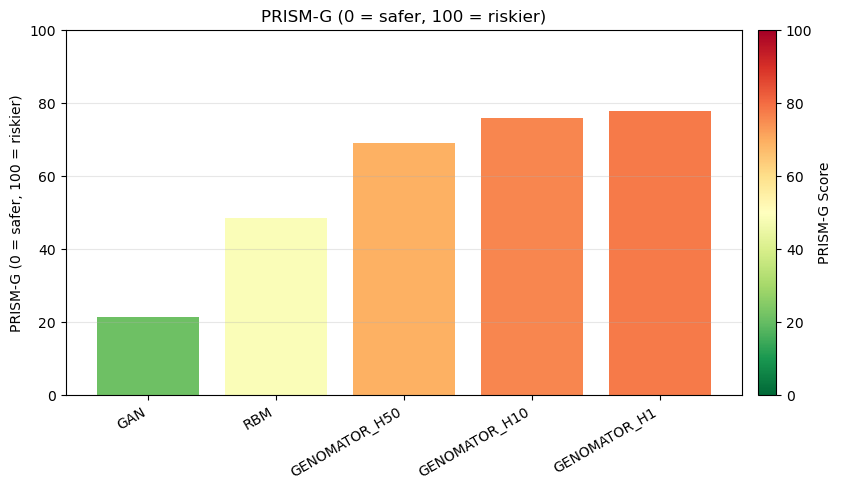

In [5]:
from prismg.utils import plotting
plotting.plot_prismg_summary(scores_df)

### Bootstrapping and pairwise comparison

To compare privacy risk scores across generators and assess robustness, PRISM-G evaluates rankings using Kendall's rank correlation coefficient. Rankings are recomputed using bootstrapping and compare with a baseline ranking obtained from the initial bootstrap draw. The average correlation measure measures the agreement between rankings and shows the stability of the resulting PRISM-G ordering.

Ranking is performed using the `bootsrap_analysis()` function from the `bootstrap` module in PRISM-G. The function requires a DataFrame containing the PRISM-G component scores (PLI, KRI, and TLI) for both the candidate generators and the reference anchors, together with a `role` column indicatin whether each dataset is a `"candidate"`, `"safe anchor"`, `"leaky anchor"`.

The function returns:

- `weights_info`: The weight vector used across all replicates.
- `tbl_stats_R`: Summary of $R_{\mathrm{raw}}$ score distributions across for each candidate.
- `tbl_stats_G`: Summary of the calibrated PRISM-G score distributions.
- `tbl_pvals`: Pairwise comparisons of PRISM-G scores (Candidate A vs Candidate B).
- `ranks`: Rankings for each bootstrap replicate.
- `kendall_summary`: Summary of the Kendall's correlation ranking test.
- `boot_G`: PRISM-G scores per replicate.

**Note:** The `boostrap_analysis()` function includes the `refit_weights` option, which defaults to `False`. When set to `True`, the component weights are re-estimated for each bootstrap relplicate before computing the PRISM-G scores.

In [6]:
import numpy as np
from prismg.bootstrap import bootstrap_analysis

RANDOM_SEED = 123
N_BOOT = 10

eps = 0.02
lam = 0.75
gamma = 0.001
w0 = [0,0,0] # Initial weight seed

weights_info, tbl_stats_R, tbl_stats_G, tbl_pvals, ranks, kendall_summary, boot_G = bootstrap_analysis(scores_df, n_boot= N_BOOT, eps=eps, lam=lam, gamma=gamma, w0=w0, refit_weights=True, random_seed= RANDOM_SEED)

if isinstance(weights_info, dict):
    print("Weights (refit each draw): mean ± sd  [n={}]:".format(weights_info["n"]))
    print(np.round(weights_info["mean"], 4), "±", np.round(weights_info["sd"], 4))
else:
    print("Baseline weights (fixed):", np.round(weights_info, 4))

print("\nBootstrap PRISM-G (means ± sd):")
print(tbl_stats_G[["name","mean_G","sd_G","ci95_G_lo","ci95_G_hi"]].round(3).to_string(index=False))

print("\nPairwise PRISM-G differences (two-sided p-values):")
print(tbl_pvals[["A_minus_B","mean_diff","ci95_diff_lo","ci95_diff_hi", "p_two_sided","p_fmt"]].to_string(index=False))

Weights (refit each draw): mean ± sd  [n=10]:
[0.401 0.06  0.539] ± [0.1667 0.032  0.1645]

Bootstrap PRISM-G (means ± sd):
         name  mean_G   sd_G  ci95_G_lo  ci95_G_hi
          RBM  68.214  9.900     50.700     76.688
 GENOMATOR_H1  49.427 16.664     34.257     77.532
GENOMATOR_H10  47.871 16.509     33.118     75.911
GENOMATOR_H50  44.727 14.688     32.202     70.153
          GAN  28.128  2.820     23.955     32.181

Pairwise PRISM-G differences (two-sided p-values):
                    A_minus_B  mean_diff  ci95_diff_lo  ci95_diff_hi  p_two_sided     p_fmt
                    GAN - RBM -40.085710    -45.279454    -25.074782          0.0  <1x10^-1
           GAN - GENOMATOR_H1 -21.298498    -51.907004     -2.192560          0.0  <1x10^-1
 GENOMATOR_H1 - GENOMATOR_H10   1.556168      1.138938      1.872997          0.0  <1x10^-1
 GENOMATOR_H1 - GENOMATOR_H50   4.700220      2.055081      7.539986          0.0  <1x10^-1
GENOMATOR_H10 - GENOMATOR_H50   3.144052      0.916143    

In [ ]:
summary = pd.DataFrame([kendall_summary])
display(summary)

,baseline,mean_tau,sd_tau,tau_ci95,perm_null_mean,perm_null_sd,p_value_two_sided,p_fmt
0,RBM > GENOMATOR_H1 > GENOMATOR_H10 > GENOMATOR...,0.78,0.289828,"[0.4, 1.0]",-0.08,0.329309,0.0,<1x10^-1


### Calibrating ridge regularization hyperparameters (Grid search evaluation)

Because the ridge regression model depends on the hyperparameters $\epsilon$, $\lambda$, and the ridge penalty strength $\gamma$, these parameters can be calibrated using a grid search to identify the combination that maximizes the agreement between the estimated and reference rankings, as measured by Kendall's correlation coefficient. 

This calibration is performed using the `grid_search()` function, where the search ranges for each hyperparameter are specified through the `eps_grid`, `lam_grid`, and `gamma_grid` arguments. The function returns a DataFrame containing the ranking results for every hyperparameter combination evaluated during the grid search.

**Note:** Grid search can be computationally intensive, particularly when using a large number of bootstrap replicates. Increasing the number of replicates generally produces more stable and reliable estimates of the ranking performance, but at the cost of longer computation times.

In [8]:
from prismg.bootstrap import grid_search

# Define the grids you want to scan
eps_grid = [0.02, 0.04, 0.06, 0.08, 0.10]
lam_grid = [0.75, 0.80, 0.85, 0.90]
gamma_grid = [1e-4, 1e-3, 1e-2]

# Run the grid search 
res = grid_search(scores_df, eps_grid=eps_grid, lam_grid=lam_grid, gamma_grid=gamma_grid, n_boot= N_BOOT, sigma=0.01, w0= w0, refit_weights=True, random_seed=RANDOM_SEED)

# See the top settings by mean Kendall τ
print(res.head(4).to_string(index=False))

 eps  lam  gamma  mean_tau   sd_tau  tau_ci_lo  tau_ci_hi  p_tau                                               modal_rank  modal_prop  N_boot  w_PLI_mean  w_KRI_mean  w_TLI_mean  w_PLI_sd  w_KRI_sd  w_TLI_sd
0.04 0.75   0.01      0.88 0.252982        0.4        1.0    0.0 RBM > GENOMATOR_H1 > GENOMATOR_H10 > GENOMATOR_H50 > GAN         0.8      10       0.397       0.048       0.555  0.103285  0.011353  0.096868
0.06 0.75   0.01      0.88 0.252982        0.4        1.0    0.0 RBM > GENOMATOR_H1 > GENOMATOR_H10 > GENOMATOR_H50 > GAN         0.8      10       0.377       0.058       0.565  0.119168  0.014757  0.110076
0.08 0.75   0.01      0.88 0.252982        0.4        1.0    0.0 RBM > GENOMATOR_H1 > GENOMATOR_H10 > GENOMATOR_H50 > GAN         0.8      10       0.358       0.068       0.574  0.135056  0.023476  0.118246
0.10 0.75   0.01      0.88 0.252982        0.4        1.0    0.0 RBM > GENOMATOR_H1 > GENOMATOR_H10 > GENOMATOR_H50 > GAN         0.8      10       0.348       0.074   

With the results obtained from the grid search evaluation, PRISM-G can be recomputed using the `r_raw`, `calibrate_to_prism` functions, or the `bootstrap_analysis` function for pairwise comparisons.

In [9]:
eps = 0.04
lam = 0.75
gamma = 0.01
w0 = [0,0,0] # Initial weight seed

weights_info, tbl_stats_R, tbl_stats_G, tbl_pvals, ranks, kendall_summary, boot_G = bootstrap_analysis(scores_df, n_boot=N_BOOT, eps=eps, lam=lam, gamma=gamma, w0=w0, refit_weights=True, random_seed=RANDOM_SEED)

if isinstance(weights_info, dict):
    print("Weights (refit each draw): mean ± sd  [n={}]:".format(weights_info["n"]))
    print(np.round(weights_info["mean"], 4), "±", np.round(weights_info["sd"], 4))
else:
    print("Baseline weights (fixed):", np.round(weights_info, 4))

print("\nBootstrap PRISM-G (means ± sd):")
print(tbl_stats_G[["name","mean_G","sd_G","ci95_G_lo","ci95_G_hi"]].round(3).to_string(index=False))

print("\nPairwise PRISM-G differences (two-sided p-values):")
print(tbl_pvals[["A_minus_B","mean_diff","ci95_diff_lo","ci95_diff_hi", "p_two_sided","p_fmt"]].to_string(index=False))

Weights (refit each draw): mean ± sd  [n=10]:
[0.397 0.048 0.555] ± [0.1033 0.0114 0.0969]

Bootstrap PRISM-G (means ± sd):
         name  mean_G   sd_G  ci95_G_lo  ci95_G_hi
          RBM  69.734  5.980     58.576     74.058
 GENOMATOR_H1  48.780 10.334     40.435     68.201
GENOMATOR_H10  47.162 10.213     38.998     66.379
GENOMATOR_H50  43.970  8.998     36.915     60.960
          GAN  28.289  1.977     24.698     30.043

Pairwise PRISM-G differences (two-sided p-values):
                    A_minus_B  mean_diff  ci95_diff_lo  ci95_diff_hi  p_two_sided     p_fmt
                    GAN - RBM -41.445061    -44.270479    -33.522970          0.0  <1x10^-1
           GAN - GENOMATOR_H1 -20.490608    -43.147369    -10.565907          0.0  <1x10^-1
          GAN - GENOMATOR_H10 -18.872673    -41.325553     -9.118085          0.0  <1x10^-1
          GAN - GENOMATOR_H50 -15.681060    -35.906489     -7.033397          0.0  <1x10^-1
 GENOMATOR_H1 - GENOMATOR_H10   1.617935      1.437028    

In [ ]:
summary = pd.DataFrame([kendall_summary])
display(summary)

,baseline,mean_tau,sd_tau,tau_ci95,perm_null_mean,perm_null_sd,p_value_two_sided,p_fmt
0,RBM > GENOMATOR_H1 > GENOMATOR_H10 > GENOMATOR...,0.88,0.252982,"[0.4, 1.0]",-0.08,0.329309,0.0,<1x10^-1


Finally, users can visualize the bootstrap results using the `plot_boot_barplot()` function, with the `boot_G` and `tbl_stats_G` tables provided as input.

(<Figure size 900x500 with 2 Axes>,
 <Axes: title={'center': 'Bootstrap PRISM-G'}, ylabel='PRISM-G (0 = safer, 100 = riskier)'>)

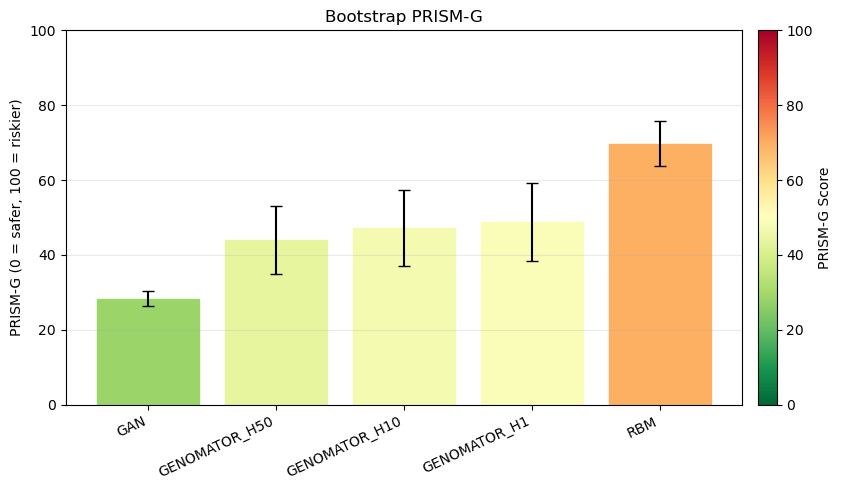

In [11]:
from prismg.utils import plotting
plotting.plot_boot_barplot(boot_G, tbl_stats_G)